In [1]:
!pip install -q torchinfo

import torch
import torch.nn as nn
import torchvision.models as models
from torchinfo import summary

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
class Backbone(nn.Module):
    def __init__(self, hidden_dim):
        super(Backbone, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        # Modify the last layer to match the required feature dimension
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, hidden_dim)

    def forward(self, x):
        return self.resnet(x)

In [3]:
import math
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_dim, max_len=100):
        super(PositionalEncoding, self).__init__()
        # Create a positional encoding matrix
        pe = torch.zeros(max_len, hidden_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_dim, 2).float() * (-math.log(10000.0) / hidden_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

In [4]:
class DetectionHead(nn.Module):
    def __init__(self, hidden_dim, num_classes, num_queries):
        super(DetectionHead, self).__init__()
        self.query_embed = nn.Embedding(num_queries, hidden_dim)
        self.transformer = nn.Transformer(d_model=hidden_dim, num_encoder_layers=6, num_decoder_layers=6)
        self.linear_class = nn.Linear(hidden_dim, num_classes) #assumes background class included in num_classes
        self.linear_bbox = nn.Linear(hidden_dim, 4)

    def forward(self, x):
        query_embeds = self.query_embed.weight.unsqueeze(1).repeat(1, x.size(0), 1)
        x = self.transformer(x, query_embeds)
        class_logits = self.linear_class(x)
        bbox_preds = self.linear_bbox(x).sigmoid()
        return class_logits, bbox_preds

In [5]:
class DETR(nn.Module):
    def __init__(self, hidden_dim, num_classes, num_queries):
        super(DETR, self).__init__()
        self.backbone = Backbone(hidden_dim)
        self.positional_encoding = PositionalEncoding(hidden_dim)
        self.detection_head = DetectionHead(hidden_dim, num_classes, num_queries)

    def forward(self, x):
        x = self.backbone(x)
        x = self.positional_encoding(x)
        class_logits, bbox_preds = self.detection_head(x)
        return {"class_logits": class_logits, "bbox_preds":bbox_preds}

In [6]:
model = DETR(hidden_dim=256, num_classes=1, num_queries=100).to(device)
summary(model, (1,3,800,1200))

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s] 
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.bat

Layer (type:depth-idx)                                       Output Shape              Param #
DETR                                                         [100, 1, 4]               --
├─Backbone: 1-1                                              [1, 256]                  --
│    └─ResNet: 2-1                                           [1, 256]                  --
│    │    └─Conv2d: 3-1                                      [1, 64, 400, 600]         9,408
│    │    └─BatchNorm2d: 3-2                                 [1, 64, 400, 600]         128
│    │    └─ReLU: 3-3                                        [1, 64, 400, 600]         --
│    │    └─MaxPool2d: 3-4                                   [1, 64, 200, 300]         --
│    │    └─Sequential: 3-5                                  [1, 256, 200, 300]        215,808
│    │    └─Sequential: 3-6                                  [1, 512, 100, 150]        1,219,584
│    │    └─Sequential: 3-7                                  [1, 1024, 50, 75] 

In [7]:
!pip install -q timm pycocotools scipy
!pip install -qU pytorch-lightning transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 67.8 MB/s eta 0:00:00:00:01:01


In [ ]:
!cd ../input/bird-manual-annotations/CVAT BIRDS ANNOTATIONS && ls

In [8]:
import torchvision
import os

class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, feature_extractor, train=True):
        ann_file = os.path.join(img_folder, "/kaggle/input/bird-manual-annotations/CVAT BIRDS ANNOTATIONS/train/annotations.json" if train else "annotations.json")
        super(CocoDetection, self).__init__(img_folder, ann_file)
        self.feature_extractor = feature_extractor

    def __getitem__(self, idx):
        # read in PIL image and target in COCO format
        img, target = super(CocoDetection, self).__getitem__(idx)
        
        # preprocess image and target (converting target to DETR format, resizing + normalization of both image and target)
        image_id = self.ids[idx]
        target = {'image_id': image_id, 'annotations': target}
        encoding = self.feature_extractor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # remove batch dimension
        target = encoding["labels"][0] # remove batch dimension

        return pixel_values, target

In [10]:
from transformers import DetrFeatureExtractor

img_folder = "/kaggle/input/bird-manual-annotations/CVAT BIRDS ANNOTATIONS"

feature_extractor = DetrFeatureExtractor.from_pretrained("facebook/detr-resnet-50")

train_dataset = CocoDetection(img_folder=f'{img_folder}/train', feature_extractor=feature_extractor)
val_dataset = CocoDetection(img_folder=f'{img_folder}/val', feature_extractor=feature_extractor, train=False)

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


/usr/local/lib/python3.10/dist-packages/transformers/models/detr/feature_extraction_detr.py:38: FutureWarning: The class DetrFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use DetrImageProcessor instead.
  warnings.warn(


In [11]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(val_dataset))

Number of training examples: 1058
Number of validation examples: 87


Image n°960


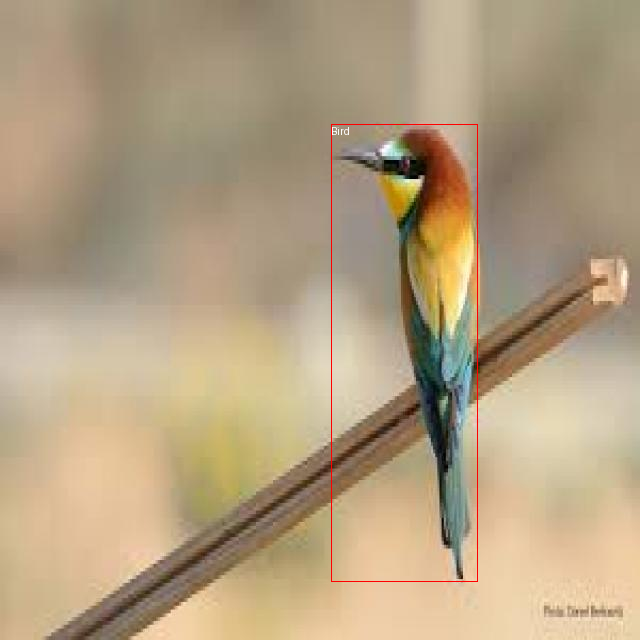

In [12]:
import numpy as np
import os
from PIL import Image, ImageDraw

# based on https://github.com/woctezuma/finetune-detr/blob/master/finetune_detr.ipynb
image_ids = train_dataset.coco.getImgIds()
# let's pick a random image
image_id = image_ids[np.random.randint(0, len(image_ids))]
print('Image n°{}'.format(image_id))
image = train_dataset.coco.loadImgs(image_id)[0]
image = Image.open(os.path.join(f'{img_folder}/train', image['file_name']))

annotations = train_dataset.coco.imgToAnns[image_id]
draw = ImageDraw.Draw(image, "RGBA")

cats = train_dataset.coco.cats
id2label = {k: v['name'] for k,v in cats.items()}

for annotation in annotations:
  box = annotation['bbox']
  class_idx = annotation['category_id']
  x,y,w,h = tuple(box)
  draw.rectangle((x,y,x+w,y+h), outline='red', width=1)
  draw.text((x, y), id2label[class_idx], fill='white')

image

In [13]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]  # Extract pixel values
    labels = [item[1] for item in batch]  # Extract labels
    
    encoding = feature_extractor.pad(pixel_values, return_tensors="pt")  # Use .pad() method

    batch = {}
    batch['pixel_values'] = encoding['pixel_values']
    
    # Check if attention_mask exists, otherwise create a mask of ones (if needed)
    batch['pixel_mask'] = encoding.get('attention_mask', torch.ones_like(batch['pixel_values'][:, 0]))  
    
    batch['labels'] = labels

    return batch

train_dataloader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn, batch_size=2)

batch = next(iter(train_dataloader))  # Fetch one batch


In [14]:
batch.keys()

dict_keys(['pixel_values', 'pixel_mask', 'labels'])

In [15]:
pixel_values, target = train_dataset[0]

In [16]:
pixel_values.shape

torch.Size([3, 800, 800])

In [17]:
pixel_values.shape

torch.Size([3, 800, 800])

In [18]:
print(target)

{'size': tensor([800, 800]), 'image_id': tensor([1]), 'class_labels': tensor([1]), 'boxes': tensor([[0.5016, 0.4975, 0.9868, 0.9851]]), 'area': tensor([622165.5625]), 'iscrowd': tensor([0]), 'orig_size': tensor([640, 640])}


In [19]:
import pytorch_lightning as pl
from transformers import DetrConfig, DetrForObjectDetection
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt

# Create a directory to store results
save_dir = "/kaggle/working/evaluation_results"
os.makedirs(save_dir, exist_ok=True)

class Detr(pl.LightningModule):
    def __init__(self, lr, lr_backbone, weight_decay):
        super().__init__()
        self.model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", 
                                                             num_labels=len(id2label),
                                                             ignore_mismatched_sizes=True)
        self.lr = lr
        self.lr_backbone = lr_backbone
        self.weight_decay = weight_decay
        self.history = []  # Store training/validation logs

    def forward(self, pixel_values, pixel_mask):
        return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)
    
    def common_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        pixel_mask = batch["pixel_mask"]
        labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]
        outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        return outputs.loss, outputs.loss_dict
    
    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("training_loss", loss)
        for k, v in loss_dict.items():
            self.log("train_" + k, v.item())
        self.history.append({"epoch": self.current_epoch, "step": batch_idx, "loss": loss.item(), "type": "train"})
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("validation_loss", loss)
        for k, v in loss_dict.items():
            self.log("validation_" + k, v.item())
        self.history.append({"epoch": self.current_epoch, "step": batch_idx, "loss": loss.item(), "type": "val"})
        return loss
    
    def configure_optimizers(self):
        param_dicts = [
            {"params": [p for n, p in self.named_parameters() if "backbone" not in n and p.requires_grad]},
            {"params": [p for n, p in self.named_parameters() if "backbone" in n and p.requires_grad], "lr": self.lr_backbone},
        ]
        return torch.optim.AdamW(param_dicts, lr=self.lr, weight_decay=self.weight_decay)
    
    def train_dataloader(self):
        return train_dataloader
    
    def val_dataloader(self):
        return val_dataloader

    def on_train_end(self):
        # Save history to CSV
        df = pd.DataFrame(self.history)
        df.to_csv(os.path.join(save_dir, "training_log.csv"), index=False)
        
        # Plot loss curves
        self.plot_loss_curve(df)
    
    def plot_loss_curve(self, df):
        plt.figure(figsize=(10, 5))
        for t in ["train", "val"]:
            subset = df[df["type"] == t]
            plt.plot(subset["epoch"], subset["loss"], label=f"{t} loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training & Validation Loss Curve")
        plt.savefig(os.path.join(save_dir, "loss_curve.png"))
        plt.close()

In [20]:
model = Detr(lr=1e-4, lr_backbone=1e-5, weight_decay=1e-4)

outputs = model(pixel_values=batch['pixel_values'], pixel_mask=batch['pixel_mask'])

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

In [21]:
outputs.logits.shape

torch.Size([4, 100, 2])

In [22]:
from pytorch_lightning import Trainer
from tqdm.notebook import tqdm

trainer = Trainer(max_steps=6625, gradient_clip_val=0.1, accelerator="auto")
trainer.fit(model)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [23]:
# Use the Trainer object to save the checkpoint after training
trainer.save_checkpoint("/kaggle/working/detr_model_checkpoint.ckpt")


In [24]:
# Save the model weights (excluding PyTorch Lightning state)
model.model.save_pretrained("/kaggle/working/detr_model_weights")


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Detected 1 objects:
Label: 38, Score: 0.9980, Box: tensor([358.3334,  52.5459, 528.8687, 286.6712])


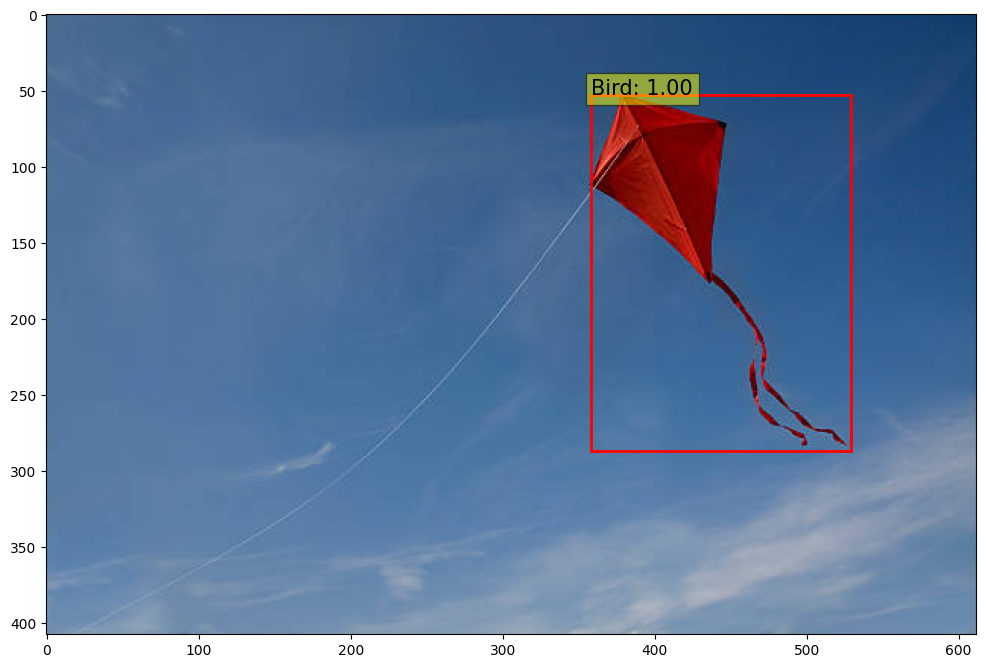

In [6]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Define the path to the saved model weights
checkpoint_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_checkpoint.ckpt"
model_weights_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_weights"

# Load the model directly from the Hugging Face model hub (use your saved weights)
# Replace with your model path, or use the Hugging Face model repository if needed
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# Load the image processor from Hugging Face model hub (use the default one)
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Set the model to evaluation mode
model.eval()

# Function to predict the image
def predict_image(image_path, threshold=0.9):
    # Open the image
    image = Image.open(image_path)

    # Preprocess the image using the processor
    inputs = processor(images=image, return_tensors="pt")

    # Perform inference and get predictions
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process the predictions
    target_sizes = torch.tensor([image.size[::-1]])  # Convert image size to [height, width]
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]

    # Visualize the predictions
    print(f"Detected {len(results['boxes'])} objects:")
    for score, label, box in zip(results['scores'], results['labels'], results['boxes']):
        print(f"Label: {label}, Score: {score:.4f}, Box: {box}")

    return results, image

# Function to visualize the predictions
def visualize_predictions(image, results):
    # Set up the plot
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image)

    # Loop over the results and draw bounding boxes
    for score, label, box in zip(results['scores'], results['labels'], results['boxes']):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        # Since you have only one class ('Bird'), we can directly label it as 'Bird'
        text = f'Bird: {score:.2f}'
        ax.text(xmin, ymin, text, fontsize=15, bbox=dict(facecolor='yellow', alpha=0.5))

    plt.show()

# Example usage: Predict on an image
image_path = "/kaggle/input/kite-images-data/kite image.jpg"  # Change to your image path
results, image = predict_image(image_path, threshold=0.3)

# Visualize the predictions
visualize_predictions(image, results)


In [ ]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Define the paths to the saved model weights and checkpoint
checkpoint_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_checkpoint.ckpt"
model_weights_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_weights"

# Load the pre-trained model (from Hugging Face)
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# Load the processor from Hugging Face
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Load custom weights with weights_only=True for safer loading
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=True)  # Safer loading
model.load_state_dict(checkpoint['state_dict'], strict=False)  # Use strict=False to ignore missing keys

# Set the model to evaluation mode
model.eval()

# Function to predict on a single frame
def predict_frame(frame, threshold=0.9):
    # Convert the frame to PIL image
    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Preprocess the image using the processor
    inputs = processor(images=image, return_tensors="pt")

    # Perform inference and get predictions
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process the predictions
    target_sizes = torch.tensor([image.size[::-1]])  # Convert image size to [height, width]
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]

    return results, image

# Function to visualize the predictions on the frame
def visualize_frame(frame, results):
    # Convert frame to RGB for visualization
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Visualize the predictions
    for score, label, box in zip(results['scores'], results['labels'], results['boxes']):
        xmin, ymin, xmax, ymax = box
        cv2.rectangle(frame_rgb, (int(xmin), int(ymin)), (int(xmax), int(ymax)), (255, 0, 0), 2)
        label_text = f'Bird: {score:.2f}'  # Change "Bird" as per your labels
        cv2.putText(frame_rgb, label_text, (int(xmin), int(ymin)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Convert RGB back to BGR for OpenCV
    return cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

# Function to predict and visualize on a video
def predict_video(video_path, output_path=None, threshold=0.3):
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Get video frame rate and resolution
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Optionally, create a VideoWriter to save output
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Perform prediction on the frame
        results, image = predict_frame(frame, threshold)

        # Visualize the results on the frame
        output_frame = visualize_frame(frame, results)

        # Display the frame
        cv2.imshow("Predicted Frame", output_frame)

        # Write the frame to the output video if saving
        if output_path:
            out.write(output_frame)

        # Press 'q' to exit early
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release resources
    cap.release()
    if output_path:
        out.release()
    cv2.destroyAllWindows()

# Example usage
video_path = "/kaggle/input/bird-images/finalbird.mp4"  # Change to your video path
output_path = "/kaggle/working/output_video.avi"  # Save output video in Kaggle working directory
predict_video(video_path, output_path, threshold=0.3)


In [ ]:
!pip install torch torchvision matplotlib pycocotools -q


In [ ]:
import torch

checkpoint_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_checkpoint.ckpt"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Print all keys in the checkpoint
print("Available keys in checkpoint:", checkpoint.keys())


In [ ]:
from IPython.display import FileLink

file_path = "/kaggle/input/50-epochs-train/detr 50 epochs output/detr_model_weights/config.json"
FileLink(file_path)
